# Options Pricing: Calls, Puts, Theory, and Graphical Intuition

This notebook is written as a beginner-friendly guide to options. We start from plain-language intuition, then gradually move to formulas and code.

If you are new to derivatives, think of an option as a **contract with flexibility**:
- a call gives flexibility to buy later at a fixed price,
- a put gives flexibility to sell later at a fixed price.

That flexibility has value, and pricing models estimate that value.

## Learning goals
- Understand call and put payoff structures
- Distinguish intrinsic value and time value
- Understand moneyness (ITM, ATM, OTM)
- Price options with Black-Scholes-Merton
- Verify put-call parity
- Compute and interpret Greeks (Delta, Gamma, Vega, Theta, Rho)
- Visualize sensitivities with graphs

## Scope and assumptions
- European options (exercise only at maturity)
- No-arbitrage, frictionless market assumptions for model formulas
- Constant volatility and rates in Black-Scholes examples
- Educational focus with transparent code and plots

## Suggested reading path
1. Section 1 to understand payoff logic.
2. First payoff chart to build visual intuition.
3. Section 2 for model formulas.
4. Pricing/Greeks table to connect formulas to numbers.
5. Final sensitivity charts for intuition about risk.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## 1. Core Option Concepts

### Option types in plain language
- **Call option**: right (not obligation) to buy the underlying at strike $K$ at maturity $T$.
- **Put option**: right (not obligation) to sell the underlying at strike $K$ at maturity $T$.

You pay an upfront **premium** to own this right.

### Why options exist
Options are widely used for:
- **Hedging**: reduce downside risk (for example, buying puts to protect a stock portfolio).
- **Directional views**: express bullish/bearish views with controlled downside.
- **Income strategies**: selling options to collect premium (with risk).

### Payoff at maturity
For terminal price $S_T$:

$$
\text{Call payoff} = \max(S_T - K, 0)
$$

$$
\text{Put payoff} = \max(K - S_T, 0)
$$

Interpretation:
- Call pays only if final price ends above strike.
- Put pays only if final price ends below strike.

### Intrinsic value and time value
Option premium before maturity can be decomposed conceptually into:
- **Intrinsic value**: value if exercised immediately.
- **Time value**: extra value due to remaining uncertainty/time.

For a call at current spot $S$:
- intrinsic value = $\max(S-K,0)$.

For a put at current spot $S$:
- intrinsic value = $\max(K-S,0)$.

### Moneyness
- **In-the-money (ITM)**:
  - call when $S>K$
  - put when $S<K$
- **At-the-money (ATM)**: approximately $S=K$
- **Out-of-the-money (OTM)**:
  - call when $S<K$
  - put when $S>K$

### Buyer vs seller payoff logic
- Option **buyer**:
  - maximum loss is limited to premium paid
  - upside can be significant (especially for calls)
- Option **seller**:
  - maximum gain is premium received
  - losses can be large (or very large for short naked calls)

### How to read the next payoff chart
- The horizontal axis is terminal underlying price $S_T$.
- The kink point is the strike $K$.
- Above/below zero line shows profit potential before considering premium.

In [2]:
def call_payoff(spot_at_maturity: np.ndarray, strike: float) -> np.ndarray:
    return np.maximum(spot_at_maturity - strike, 0.0)


def put_payoff(spot_at_maturity: np.ndarray, strike: float) -> np.ndarray:
    return np.maximum(strike - spot_at_maturity, 0.0)


strike = 100.0
spot_grid = np.linspace(40, 160, 13)
payoff_df = pd.DataFrame(
    {
        "S_T": spot_grid,
        "long_call_payoff": call_payoff(spot_grid, strike),
        "long_put_payoff": put_payoff(spot_grid, strike),
    }
)
payoff_df

,S_T,long_call_payoff,long_put_payoff
0,40.000000,0.000000,60.000000
1,50.000000,0.000000,50.000000
2,60.000000,0.000000,40.000000
3,70.000000,0.000000,30.000000
4,80.000000,0.000000,20.000000
5,90.000000,0.000000,10.000000
6,100.000000,0.000000,0.000000
7,110.000000,10.000000,0.000000
8,120.000000,20.000000,0.000000
9,130.000000,30.000000,0.000000


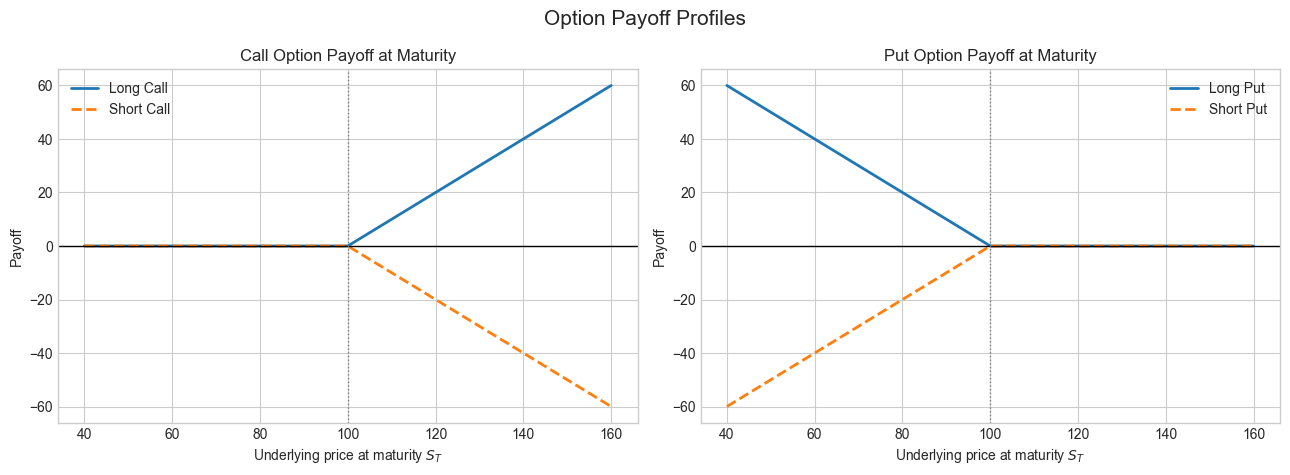

In [3]:
dense_spot_grid = np.linspace(40, 160, 400)
long_call = call_payoff(dense_spot_grid, strike)
long_put = put_payoff(dense_spot_grid, strike)
short_call = -long_call
short_put = -long_put

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(dense_spot_grid, long_call, linewidth=2, label="Long Call")
axes[0].plot(dense_spot_grid, short_call, linewidth=2, linestyle="--", label="Short Call")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axvline(strike, color="gray", linestyle=":", linewidth=1)
axes[0].set_title("Call Option Payoff at Maturity")
axes[0].set_xlabel("Underlying price at maturity $S_T$")
axes[0].set_ylabel("Payoff")
axes[0].legend()

axes[1].plot(dense_spot_grid, long_put, linewidth=2, label="Long Put")
axes[1].plot(dense_spot_grid, short_put, linewidth=2, linestyle="--", label="Short Put")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].axvline(strike, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Put Option Payoff at Maturity")
axes[1].set_xlabel("Underlying price at maturity $S_T$")
axes[1].set_ylabel("Payoff")
axes[1].legend()

fig.suptitle("Option Payoff Profiles", fontsize=15)
fig.tight_layout()
plt.show()

## 2. Black-Scholes-Merton Pricing for European Options

Black-Scholes is a foundational model that gives a closed-form fair value for European call and put options under simplifying assumptions.

### Model inputs and intuition
- $S$: current underlying price. Higher $S$ usually helps calls and hurts puts.
- $K$: strike price. Higher $K$ usually hurts calls and helps puts.
- $T$: time to maturity in years. More time usually means more option value.
- $r$: risk-free continuously compounded rate.
- $\sigma$: volatility. Higher volatility usually increases both call and put prices.

### Core formulas

$$
d_1 = \frac{\ln(S/K) + (r + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}},
\qquad
d_2 = d_1 - \sigma\sqrt{T}
$$

$$
C = S N(d_1) - K e^{-rT} N(d_2)
$$

$$
P = K e^{-rT} N(-d_2) - S N(-d_1)
$$

Here $N(\cdot)$ is the standard normal cumulative distribution function.

### Put-call parity (consistency check)
For non-dividend assets:

$$
C - P = S - K e^{-rT}
$$

If this does not hold, there may be an arbitrage opportunity or inconsistent market quotes.

### Greeks intuition for beginners
- **Delta**: "speed" of option price change when spot changes a little.
- **Gamma**: how quickly delta itself changes.
- **Vega**: sensitivity to volatility assumptions.
- **Theta**: impact of time passing (time decay).
- **Rho**: sensitivity to interest rates.

### How to read the next outputs
- The table shows model prices and Greeks for one parameter set.
- The next graph shows how price, delta, and gamma change as spot moves.
- The final graph block shows how option value reacts to volatility and maturity.

In [4]:
def bs_d1_d2(spot: float, strike: float, maturity: float, rate: float, vol: float) -> tuple[float, float]:
    sigma_sqrt_t = vol * math.sqrt(maturity)
    d1 = (math.log(spot / strike) + (rate + 0.5 * vol ** 2) * maturity) / sigma_sqrt_t
    d2 = d1 - sigma_sqrt_t
    return d1, d2


def bs_call_price(spot: float, strike: float, maturity: float, rate: float, vol: float) -> float:
    d1, d2 = bs_d1_d2(spot, strike, maturity, rate, vol)
    return float(spot * norm.cdf(d1) - strike * math.exp(-rate * maturity) * norm.cdf(d2))


def bs_put_price(spot: float, strike: float, maturity: float, rate: float, vol: float) -> float:
    d1, d2 = bs_d1_d2(spot, strike, maturity, rate, vol)
    return float(strike * math.exp(-rate * maturity) * norm.cdf(-d2) - spot * norm.cdf(-d1))


def bs_greeks(spot: float, strike: float, maturity: float, rate: float, vol: float) -> dict:
    d1, d2 = bs_d1_d2(spot, strike, maturity, rate, vol)
    pdf_d1 = norm.pdf(d1)

    call_delta = norm.cdf(d1)
    put_delta = call_delta - 1.0
    gamma = pdf_d1 / (spot * vol * math.sqrt(maturity))
    vega = spot * pdf_d1 * math.sqrt(maturity)

    call_theta = -(spot * pdf_d1 * vol) / (2 * math.sqrt(maturity)) - rate * strike * math.exp(-rate * maturity) * norm.cdf(d2)
    put_theta = -(spot * pdf_d1 * vol) / (2 * math.sqrt(maturity)) + rate * strike * math.exp(-rate * maturity) * norm.cdf(-d2)

    call_rho = strike * maturity * math.exp(-rate * maturity) * norm.cdf(d2)
    put_rho = -strike * maturity * math.exp(-rate * maturity) * norm.cdf(-d2)

    return {
        "call_delta": float(call_delta),
        "put_delta": float(put_delta),
        "gamma": float(gamma),
        "vega": float(vega),
        "call_theta": float(call_theta),
        "put_theta": float(put_theta),
        "call_rho": float(call_rho),
        "put_rho": float(put_rho),
    }

In [5]:
spot = 100.0
strike = 100.0
maturity = 1.0
rate = 0.04
vol = 0.22

call_price = bs_call_price(spot, strike, maturity, rate, vol)
put_price = bs_put_price(spot, strike, maturity, rate, vol)
greeks = bs_greeks(spot, strike, maturity, rate, vol)

parity_lhs = call_price - put_price
parity_rhs = spot - strike * math.exp(-rate * maturity)

summary_df = pd.DataFrame(
    {
        "metric": [
            "Call Price",
            "Put Price",
            "Put-Call Parity LHS (C-P)",
            "Put-Call Parity RHS (S-Ke^{-rT})",
            "Parity Difference",
            "Call Delta",
            "Put Delta",
            "Gamma",
            "Vega",
            "Call Theta",
            "Put Theta",
            "Call Rho",
            "Put Rho",
        ],
        "value": [
            call_price,
            put_price,
            parity_lhs,
            parity_rhs,
            parity_lhs - parity_rhs,
            greeks["call_delta"],
            greeks["put_delta"],
            greeks["gamma"],
            greeks["vega"],
            greeks["call_theta"],
            greeks["put_theta"],
            greeks["call_rho"],
            greeks["put_rho"],
        ],
    }
)
summary_df

,metric,value
0,Call Price,10.688823
1,Put Price,6.767767
2,Put-Call Parity LHS (C-P),3.921056
3,Put-Call Parity RHS (S-Ke^{-rT}),3.921056
4,Parity Difference,0.000000
5,Call Delta,0.614787
6,Put Delta,-0.385213
7,Gamma,0.017378
8,Vega,38.231230
9,Call Theta,-6.237031


## How to Read the Pricing Output

This table uses one specific setup ($S=100$, $K=100$, $T=1$, $r=4\%$, $\sigma=22\%$).

What to focus on:
- **Call Price / Put Price**: theoretical values under the model assumptions.
- **Put-Call Parity LHS and RHS**: should be nearly identical.
- **Parity Difference**: ideally close to zero (rounding noise only).
- **Greeks**: first-order and second-order sensitivities used in risk management.

Practical interpretation:
- Call delta around 0.61 means a +1 move in spot changes call value by about +0.61 (locally).
- Gamma being positive means delta increases as spot rises.
- Negative theta means option loses value as time passes, all else equal.

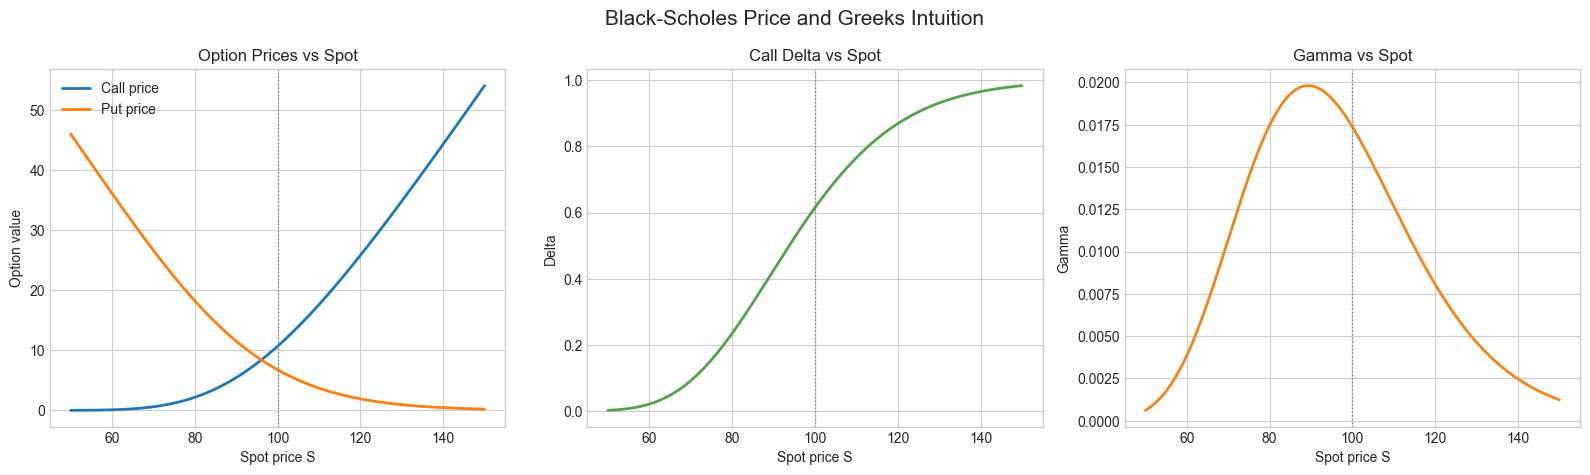

In [6]:
spot_range = np.linspace(50, 150, 200)
call_prices = np.array([bs_call_price(s, strike, maturity, rate, vol) for s in spot_range])
put_prices = np.array([bs_put_price(s, strike, maturity, rate, vol) for s in spot_range])
call_delta_curve = np.array([bs_greeks(s, strike, maturity, rate, vol)["call_delta"] for s in spot_range])
gamma_curve = np.array([bs_greeks(s, strike, maturity, rate, vol)["gamma"] for s in spot_range])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].plot(spot_range, call_prices, linewidth=2, label="Call price")
axes[0].plot(spot_range, put_prices, linewidth=2, label="Put price")
axes[0].axvline(strike, color="gray", linestyle=":", linewidth=1)
axes[0].set_title("Option Prices vs Spot")
axes[0].set_xlabel("Spot price S")
axes[0].set_ylabel("Option value")
axes[0].legend()

axes[1].plot(spot_range, call_delta_curve, linewidth=2, color="#54A24B")
axes[1].axvline(strike, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Call Delta vs Spot")
axes[1].set_xlabel("Spot price S")
axes[1].set_ylabel("Delta")

axes[2].plot(spot_range, gamma_curve, linewidth=2, color="#F58518")
axes[2].axvline(strike, color="gray", linestyle=":", linewidth=1)
axes[2].set_title("Gamma vs Spot")
axes[2].set_xlabel("Spot price S")
axes[2].set_ylabel("Gamma")

fig.suptitle("Black-Scholes Price and Greeks Intuition", fontsize=15)
fig.tight_layout()
plt.show()

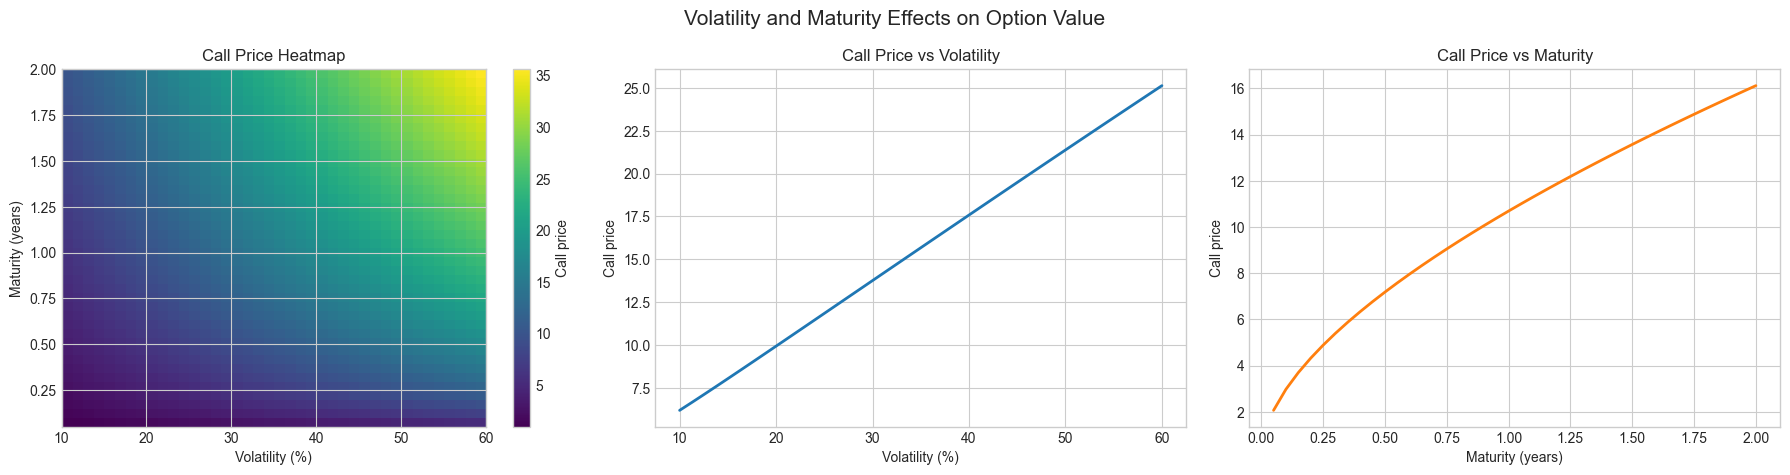

In [8]:
vol_grid = np.linspace(0.10, 0.60, 40)
time_grid = np.linspace(0.05, 2.0, 40)

call_surface = np.array(
    [[bs_call_price(spot, strike, t, rate, sigma) for sigma in vol_grid] for t in time_grid]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

im0 = axes[0].imshow(
    call_surface,
    aspect="auto",
    origin="lower",
    extent=[100 * vol_grid.min(), 100 * vol_grid.max(), time_grid.min(), time_grid.max()],
    cmap="viridis",
)
axes[0].set_title("Call Price Heatmap")
axes[0].set_xlabel("Volatility (%)")
axes[0].set_ylabel("Maturity (years)")
fig.colorbar(im0, ax=axes[0], label="Call price")

vol_sensitivity = [bs_call_price(spot, strike, maturity, rate, sigma) for sigma in vol_grid]
axes[1].plot(100 * vol_grid, vol_sensitivity, linewidth=2, color="#1f77b4")
axes[1].set_title("Call Price vs Volatility")
axes[1].set_xlabel("Volatility (%)")
axes[1].set_ylabel("Call price")

time_sensitivity = [bs_call_price(spot, strike, t, rate, vol) for t in time_grid]
axes[2].plot(time_grid, time_sensitivity, linewidth=2, color="#ff7f0e")
axes[2].set_title("Call Price vs Maturity")
axes[2].set_xlabel("Maturity (years)")
axes[2].set_ylabel("Call price")

fig.suptitle("Volatility and Maturity Effects on Option Value", fontsize=15)
fig.tight_layout()
plt.show()

## Main Takeaways (Beginner Recap)

- A call is valuable when price goes above strike; a put is valuable when price goes below strike.
- Option premium is not only intrinsic value; time and uncertainty add extra value.
- Black-Scholes is a benchmark model: useful for intuition, quoting, and risk decomposition.
- Put-call parity is a key sanity check for consistent pricing.
- Greeks turn "price intuition" into measurable risk sensitivities.

Practical beginner checklist when analyzing an option:
1. Check moneyness (ITM/ATM/OTM).
2. Check time to maturity.
3. Check implied/assumed volatility level.
4. Inspect delta and gamma for spot risk.
5. Inspect theta for time decay.
6. Verify parity consistency when comparing call and put quotes.

Possible next extensions:
- Dividends and foreign-currency underlyings
- Implied volatility extraction from market prices
- Binomial trees and Monte Carlo pricing
- American option early exercise analysis